sigma_w2 (W) = 6.497337271429522e-13
Path Loss 1m = 41.984197280441926
Gerando exemplo de visualização da topologia da rede
Cenário I: M=100, K=20


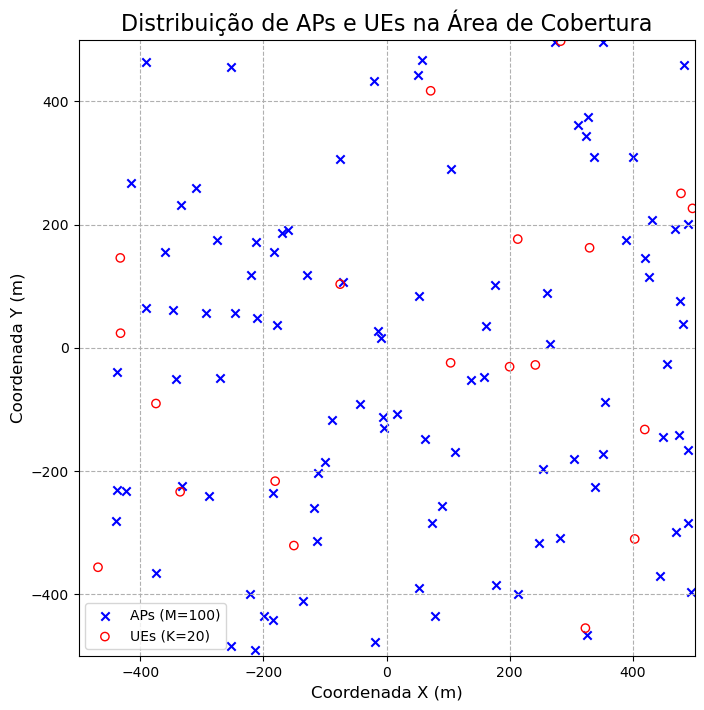

Cenário I: M=150, K=20


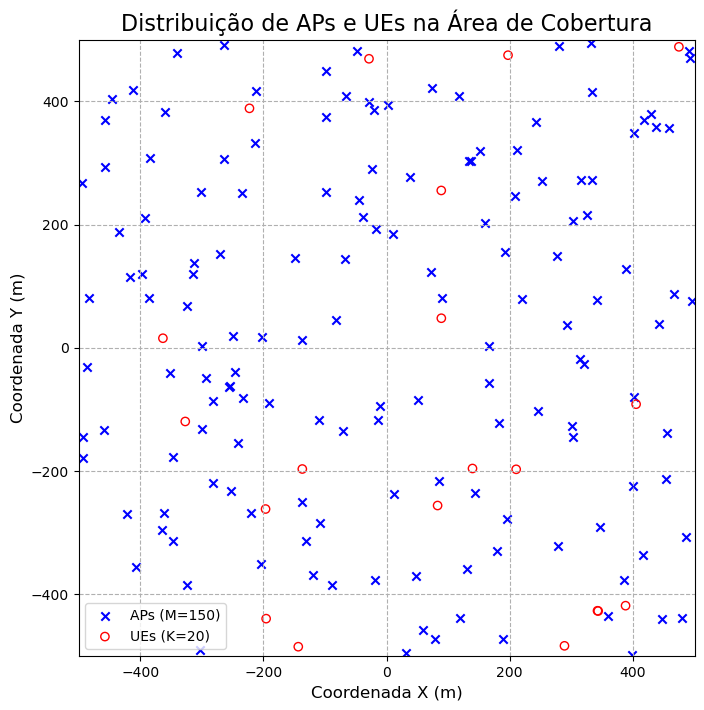

Cenário I: M=200, K=20


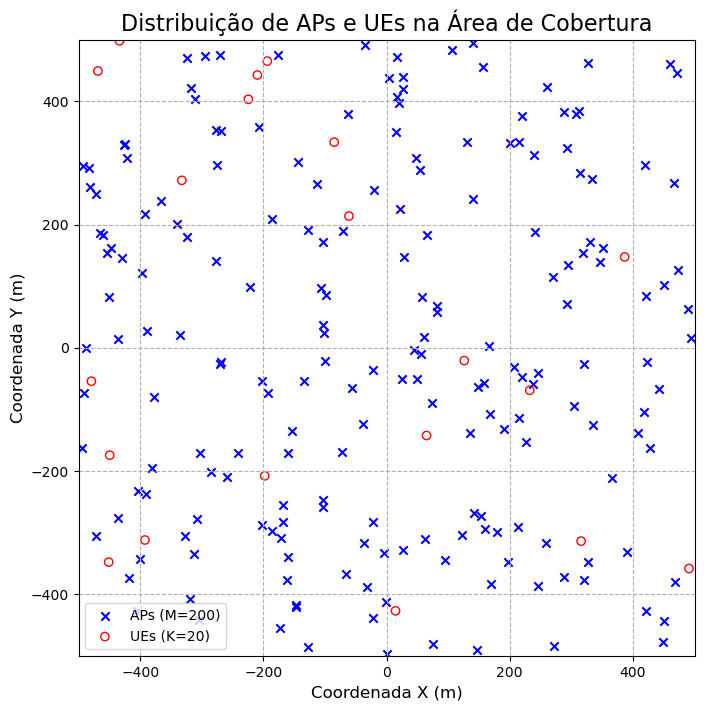

Cenário II: M=100, K=10


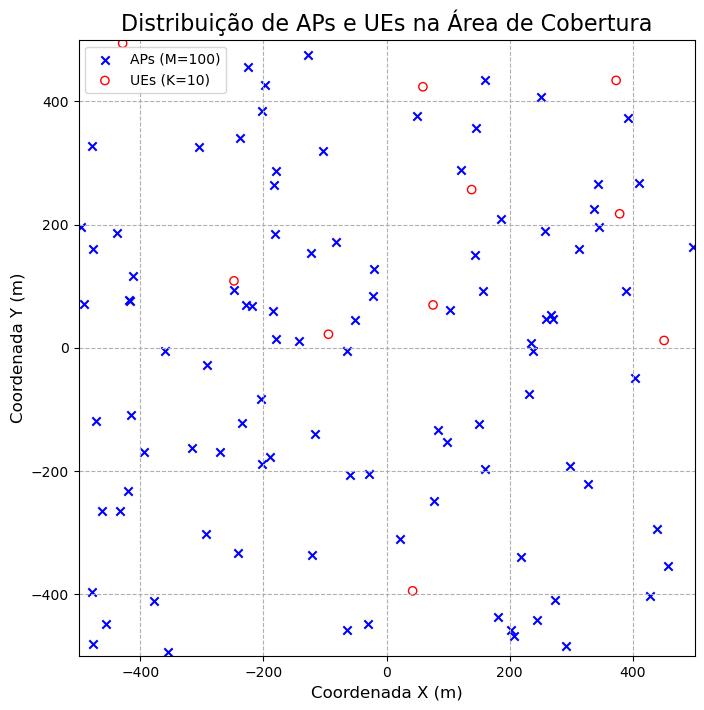

Cenário II: M=100, K=20


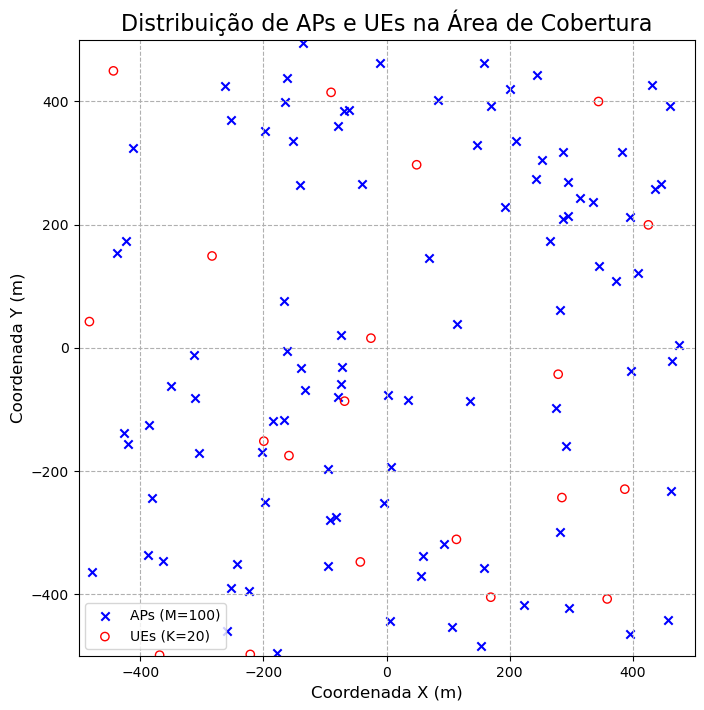

Cenário II: M=100, K=30


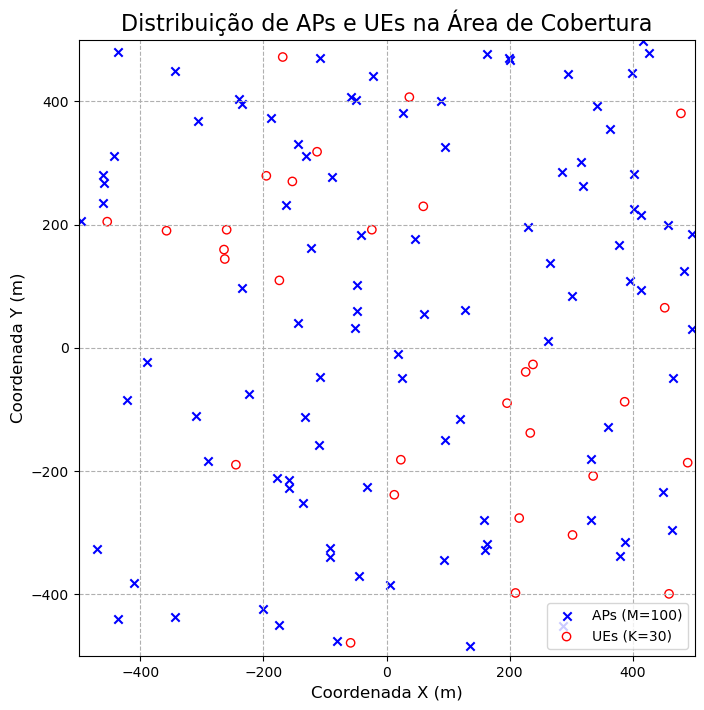

Cenário I: M=100, K=20
Tempo total: 2.26 minutos
Tempo em segundos: 135.7627s
Cenário I: M=150, K=20
Tempo total: 4.86 minutos
Tempo em segundos: 291.4836s
Cenário I: M=200, K=20
Tempo total: 7.58 minutos
Tempo em segundos: 454.8139s
Cenário II: M=100, K=10
Tempo total: 8.21 minutos
Tempo em segundos: 492.4726s
Cenário II: M=100, K=20
Tempo total: 10.58 minutos
Tempo em segundos: 634.9379s
Cenário II: M=100, K=30
Tempo total: 15.85 minutos
Tempo em segundos: 950.8989s


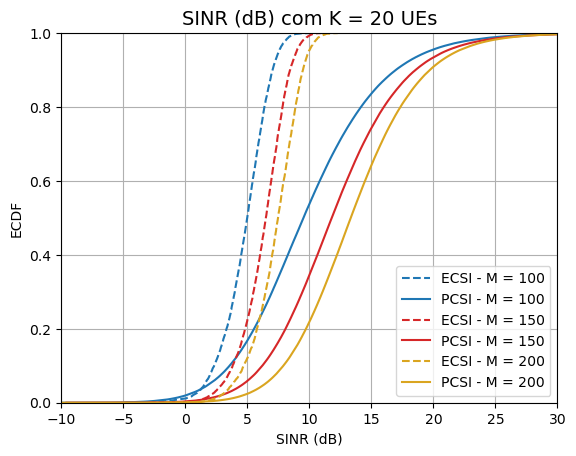

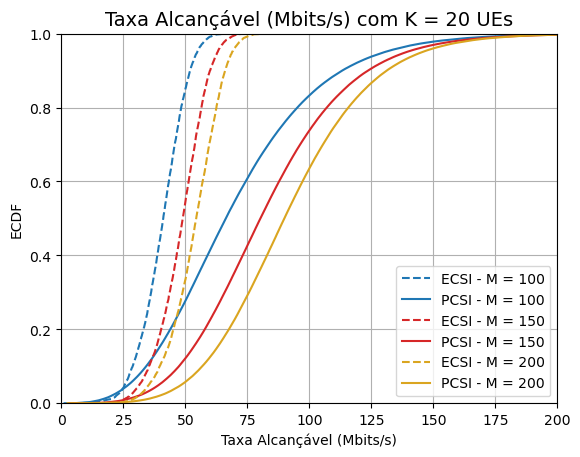

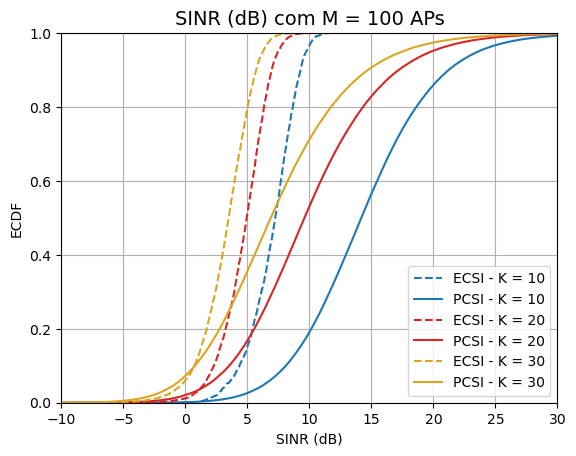

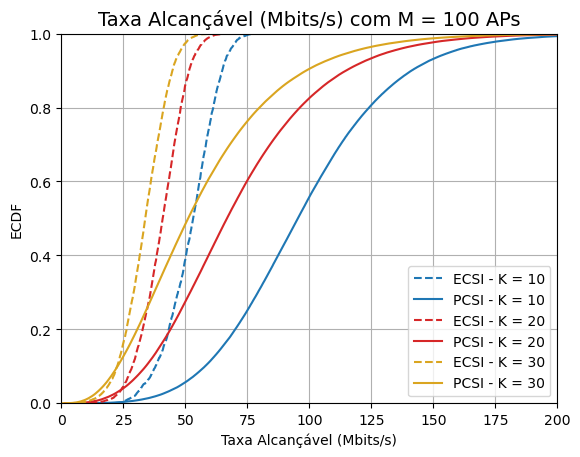

In [8]:
#UNIVERSIDADE DE BRASÍLIA 
#FACULDADE DE TECNOLOGIA
#DEPARTAMENTO DE ENGENHARIA ELÉTRICA
#PROGRAMA DE PÓS-GRADUAÇÃO EM ENGENHARIA ELÉTRICA
#PPGEE3622 – COMUNICAÇÕES MÓVEIS
#TAKESHI IKEDA - 252104269
#ATIVIDADE 03
#SIMULAÇÃO DAS REDES CELL-FREE
#DOCENTE: HIGO THAIAN PEREIRA DA SILVA


import numpy as np
import matplotlib.pyplot as plt

import time
from datetime import timedelta


# Parâmetros  Gerais

# Velocidade da luz (m/s)
c = 3e8

# Constante de Boltzmann (J/K) 
k0 = 1.381e-23

# Parâmetros  Gerais Fornecidos (Tabela 1)
# Frequencia central - 3 GHz - fc representado em Hz
fc = 3e9

# Largura de banda - 20 MHz Bw representado em Hz
Bw = 20e6

# Figura de Ruido - 9 dB
Fn_dB = 9
# Converter Figura de Ruido para linear
Fn = 10**(Fn_dB/10)

# Altura do AP - 15 m
hAP = 15

# Altura do UE - 1,65 m
hUE = 1.65

# Temperatura em Kelvin - 296,15 K
T = 296.15

# Dimensões da área coberta 1000 m x 1000 m
Lx = 1000
Ly = 1000

# Número de blocos de coerència - 100 
Nbc = 100

#  Número de redes avaliadas - 300
Ncf = 300

# Comprimento das sequencias piloto - tau_p -  50
tau_p = 50

# Potencia das sequências Piloto - 200 mW / 0,2 W
P_p = 0.2

# Potencia de transmissão em downlink - 200 mW / 0,2 W
P_dl = 0.2

# Potência de ruído sigma_w2
sigma_w2 = k0 * T * Bw * Fn
print("sigma_w2 (W) =", sigma_w2)

# Fixar o valor da Semente na geração das variáveis aleatórias

semente = 2025

# Cenários
M_list = [100, 150, 200]
K_fixed_sit1 = 20
M_fixed_sit2 = 100
K_list = [10, 20, 30]


# Modelo Close in Free Space
# PL_1m + 28*log10(d) + X_sf

# Free Space Loss para 1 m - PL_1m
PL_1m = 20 * np.log10(4 * np.pi * fc / c)
print("Path Loss 1m =", PL_1m)

# Variável aleatória gaussiana X_Sf de média 0 dB e Desvio padrão de 8 dB
shadow_sigma_db = 8

# Fator multiplicando o Log10 (distância) - Modelo Close in Free Space
pathloss_exponent_db = 28

rng = np.random.default_rng(semente)

# Funções

def formatar_tempo(segundos):
    """
    Formata o tempo em segundos para uma string legível.
    Retorna em horas, minutos ou segundos conforme o valor.
    """
    if segundos < 60:
        return f"{segundos:.2f} segundos"
    elif segundos < 3600:
        minutos = segundos / 60
        return f"{minutos:.2f} minutos"
    else:
        horas = segundos / 3600
        return f"{horas:.2f} horas"


inicio = time.time()


# Gerar as posições dos APs e UEs
def generate_positions(M, K):
    x_AP = rng.uniform(-Lx/2, Lx/2, size=M)
    y_AP = rng.uniform(-Ly/2, Ly/2, size=M)
    p_AP = np.vstack([x_AP, y_AP, np.full(M, hAP)]).T
    x_UE = rng.uniform(-Lx/2, Lx/2, size=K)
    y_UE = rng.uniform(-Ly/2, Ly/2, size=K)
    p_UE = np.vstack([x_UE, y_UE, np.full(K, hUE)]).T
    return p_AP, p_UE

# Calcula as distânias das posições do AP e UE, considerando inclusive a altura (3D)
def distances(p_AP, p_UE):
    diff = p_AP[:, None, :] - p_UE[None, :, :]
    return np.linalg.norm(diff, axis=2)

# Desvanecimento em Larga Escala
def large_scale_gain(d):
    tem_menor_que_1 = np.any(d < 1.0)
    if tem_menor_que_1:
#        print("Foram encontrados valores menores que 1.")
        d_clipped = np.maximum(d, 1.0)
        shadow = rng.normal(0.0, shadow_sigma_db, size=d_clipped.shape)
        Omega_dB = PL_1m + pathloss_exponent_db * np.log10(d_clipped) + shadow
        return 10**(-Omega_dB/10.0), Omega_dB
    else:    
#        print("Nenhum valor menor que 1.")
        shadow = rng.normal(0.0, shadow_sigma_db, size=d.shape)
        Omega_dB = PL_1m + pathloss_exponent_db * np.log10(d) + shadow
        return 10**(-Omega_dB/10.0), Omega_dB


# Desvanecimento em pequena escala
def small_scale_rayleigh(M, K):
    real = rng.normal(0.0, np.sqrt(1/2), size=(M,K))
    imag = rng.normal(0.0, np.sqrt(1/2), size=(M,K))
    return real + 1j*imag

# CDF Empirica
def ecdf(data):
    data = np.sort(data)
    y = np.arange(1, len(data)+1) / len(data)
    return data, y

# Visualização da distribuição dos APs e UEs 
def plot_ap_ue_locations(ap_locations, ue_locations, Lx, Ly):
    """
    Plota a posição dos APs e UEs na área de cobertura.
    O centro da área é (0,0).
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plotar APs
    ax.scatter(ap_locations[:, 0], ap_locations[:, 1], 
               marker='x', color='blue', label=f'APs (M={len(ap_locations)})')
    
    # Plotar UEs
    ax.scatter(ue_locations[:, 0], ue_locations[:, 1], 
               marker='o', facecolors='none', edgecolors='red', label=f'UEs (K={len(ue_locations)})')
    
    # Configurar o gráfico
    ax.set_title('Distribuição de APs e UEs na Área de Cobertura', fontsize=16)
    ax.set_xlabel('Coordenada X (m)', fontsize=12)
    ax.set_ylabel('Coordenada Y (m)', fontsize=12)
    ax.set_xlim(-Lx / 2, Lx / 2)
    ax.set_ylim(-Ly / 2, Ly / 2)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--')
    ax.legend()
    
    plt.show()

# Visualização da Posição dos APs e UEs (Exemplos) ---
print("Gerando exemplo de visualização da topologia da rede")


for M in M_list:
    print(f"Cenário I: M={M}, K=20")
    x_AP = rng.uniform(-Lx/2, Lx/2, size=M)
    y_AP = rng.uniform(-Ly/2, Ly/2, size=M)
    ap_locations = np.column_stack([x_AP, y_AP])
    x_UE = rng.uniform(-Lx/2, Lx/2, size=K_fixed_sit1)
    y_UE = rng.uniform(-Ly/2, Ly/2, size=K_fixed_sit1)
    ue_locations = np.column_stack([x_UE, y_UE])
    plot_ap_ue_locations(ap_locations, ue_locations, Lx, Ly)
    

for K in K_list:
    print(f"Cenário II: M=100, K={K}")
    x_AP = rng.uniform(-Lx/2, Lx/2, size=M_fixed_sit2)
    y_AP = rng.uniform(-Ly/2, Ly/2, size=M_fixed_sit2)
    ap_locations = np.column_stack([x_AP, y_AP])
    x_UE = rng.uniform(-Lx/2, Lx/2, size=K)
    y_UE = rng.uniform(-Ly/2, Ly/2, size=K)
    ue_locations = np.column_stack([x_UE, y_UE])
    plot_ap_ue_locations(ap_locations, ue_locations, Lx, Ly)


# Implementação
def simulate_user_formula(M, K, Ncf=Ncf, Nbc=Nbc):
    sinr_inst_all = []
    sinr_stat_all = []
    rate_inst_all = []
    rate_stat_all = []

    c_coef = 1.0 / np.sqrt(tau_p * P_p)

    for _ in range(Ncf):

        p_AP, p_UE = generate_positions(M, K)
        d = distances(p_AP, p_UE)
        Omega_lin, _ = large_scale_gain(d)

        gamma = np.sqrt(P_dl * tau_p) * Omega_lin * c_coef
        eta = 1.0 / np.sum(gamma, axis=1)
        eta = np.repeat(eta[:,None], K, axis=1)

        numer_stat = P_dl * (np.sum(np.sqrt(eta) * gamma, axis=0))**2
        sum_eta_gamma = np.sum(eta * gamma, axis=1)
        denom_stat = P_dl * np.sum(Omega_lin * sum_eta_gamma[:,None], axis=0) + sigma_w2
        sinr_stat = numer_stat / denom_stat

        sinr_stat_all.extend(sinr_stat)
        rate_stat_all.extend(np.log2(1 + sinr_stat))

        for _ in range(Nbc):
            h = small_scale_rayleigh(M, K)
            g = np.sqrt(Omega_lin) * h

            v = (rng.normal(0,np.sqrt(sigma_w2/2),(M,K)) +
                 1j*rng.normal(0,np.sqrt(sigma_w2/2),(M,K)))

            g_hat = g + v / np.sqrt(tau_p * P_p)

            sinr_k = np.zeros(K)
            for k in range(K):
                num = P_dl * np.abs(np.sum(np.sqrt(eta[:,k])*g[:,k]*np.conj(g_hat[:,k])))**2

                interf = 0
                for kp in range(K):
                    if kp != k:
                        interf += np.abs(np.sum(np.sqrt(eta[:,kp])*g[:,k]*np.conj(g_hat[:,kp])))**2

                sinr_k[k] = num / (P_dl * interf + sigma_w2)

            sinr_inst_all.extend(sinr_k)
            rate_inst_all.extend(np.log2(1 + sinr_k))

    return {
        'sinr_inst': np.array(sinr_inst_all),
        'sinr_stat': np.array(sinr_stat_all),
        'rate_inst': np.array(rate_inst_all),
        'rate_stat': np.array(rate_stat_all)
    }

# SIMULAÇÕES
results_sit1 = {}
for M in M_list:
    print(f"Cenário I: M={M}, K=20")
    results_sit1[M] = simulate_user_formula(M, K_fixed_sit1)
    fim = time.time()
    # Calcula o tempo decorrido
    tempo_decorrido = fim - inicio
    # Formata e exibe o resultado
    tempo_formatado = formatar_tempo(tempo_decorrido)
    print(f"Tempo total: {tempo_formatado}")
    print(f"Tempo em segundos: {tempo_decorrido:.4f}s")

results_sit2 = {}
for K in K_list:
    print(f"Cenário II: M=100, K={K}")
    results_sit2[K] = simulate_user_formula(M_fixed_sit2, K)
    fim = time.time()
    # Calcula o tempo decorrido
    tempo_decorrido = fim - inicio
    # Formata e exibe o resultado
    tempo_formatado = formatar_tempo(tempo_decorrido)
    print(f"Tempo total: {tempo_formatado}")
    print(f"Tempo em segundos: {tempo_decorrido:.4f}s")


# GRÁFICO 1 — SINR (Cenário I)
plt.figure()
for M, c in zip([100,150,200], ['tab:blue','tab:red','goldenrod']):
    x,y = ecdf(10*np.log10(results_sit1[M]['sinr_stat']+1e-12))
    plt.plot(x,y,'--',color=c,label=f'ECSI - M = {M}')
    x,y = ecdf(10*np.log10(results_sit1[M]['sinr_inst']+1e-12))
    plt.plot(x,y,'-',color=c,label=f'PCSI - M = {M}')
plt.title('SINR (dB) com K = 20 UEs', fontsize=14)
plt.xlabel('SINR (dB)')
plt.ylabel('ECDF')
plt.xlim([-10,30])
plt.ylim([0,1])
plt.grid()
plt.legend(loc='lower right')   # <<< ALTERAÇÃO SOLICITADA
plt.show()

# GRÁFICO 2 — TAXA ALCANCAVEL (Cenário I)
plt.figure()
for M, c in zip([100,150,200], ['tab:blue','tab:red','goldenrod']):
    x,y = ecdf(Bw * results_sit1[M]['rate_stat'] / 1e6)
    plt.plot(x,y,'--',color=c,label=f'ECSI - M = {M}')
    x,y = ecdf(Bw * results_sit1[M]['rate_inst'] / 1e6)
    plt.plot(x,y,'-',color=c,label=f'PCSI - M = {M}')
plt.title('Taxa Alcançável (Mbits/s) com K = 20 UEs', fontsize=14)
plt.xlabel('Taxa Alcançável (Mbits/s)')
plt.ylabel('ECDF')
plt.xlim([0,200]) #aumentar para 200 Mbits/s
plt.ylim([0,1])
plt.grid()
plt.legend()
plt.show()

# GRÁFICO 3 — SINR (Cenário II)
plt.figure()
for K, c in zip([10,20,30], ['tab:blue','tab:red','goldenrod']):
    x,y = ecdf(10*np.log10(results_sit2[K]['sinr_stat']+1e-12))
    plt.plot(x,y,'--',color=c,label=f'ECSI - K = {K}')
    x,y = ecdf(10*np.log10(results_sit2[K]['sinr_inst']+1e-12))
    plt.plot(x,y,'-',color=c,label=f'PCSI - K = {K}')
plt.title('SINR (dB) com M = 100 APs', fontsize=14)
plt.xlabel('SINR (dB)')
plt.ylabel('ECDF')
plt.xlim([-10,30])
plt.ylim([0,1])
plt.grid()
plt.legend(loc='lower right')   # <<< ALTERAÇÃO SOLICITADA
plt.show()

# GRÁFICO 4 — TAXA ALCANCAVEL (Cenário II)
plt.figure()
for K, c in zip([10,20,30], ['tab:blue','tab:red','goldenrod']):
    x,y = ecdf(Bw * results_sit2[K]['rate_stat'] / 1e6)
    plt.plot(x,y,'--',color=c,label=f'ECSI - K = {K}')
    x,y = ecdf(Bw * results_sit2[K]['rate_inst'] / 1e6)
    plt.plot(x,y,'-',color=c,label=f'PCSI - K = {K}')
plt.title('Taxa Alcançável (Mbits/s) com M = 100 APs', fontsize=14)
plt.xlabel('Taxa Alcançável (Mbits/s)')
plt.ylabel('ECDF')
plt.xlim([0,200]) #aumentar para 200 Mbits/s
plt.ylim([0,1])
plt.grid()
plt.legend()
plt.show()